# Redes Neurais

## MLP

In [1]:
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

In [2]:
digits = load_digits()
X,y = digits.data, digits.target

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

In [4]:
mlp = MLPClassifier(hidden_layer_sizes=(50), max_iter=500, random_state=42)
mlp.fit(X_train, y_train)

MLPClassifier(hidden_layer_sizes=50, max_iter=500, random_state=42)

In [5]:
y_pred = mlp.predict(X_test)
print(f"Acurácia: {accuracy_score(y_test, y_pred):.3f}")

Acurácia: 0.969


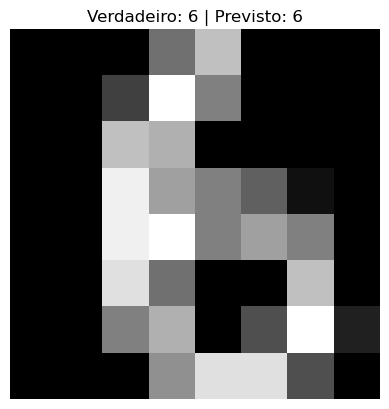

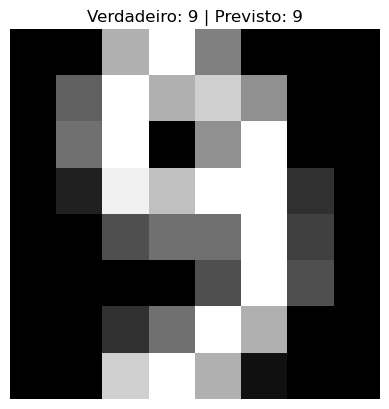

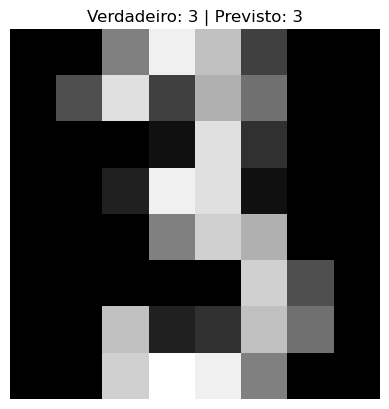

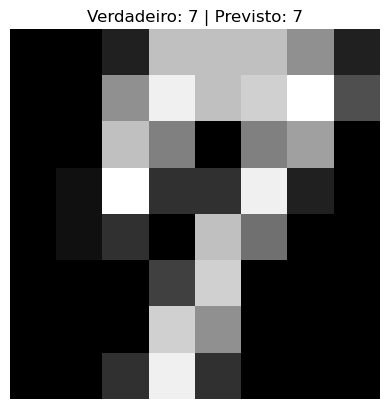

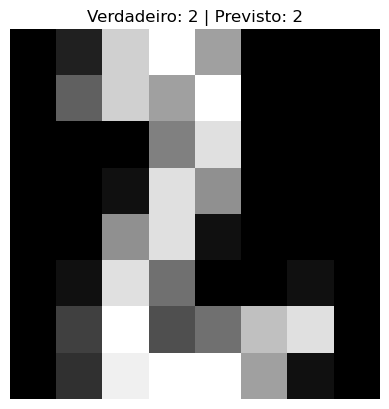

In [6]:
# Visualização
for i in range(5):
    plt.imshow(X_test[i].reshape(8, 8), cmap="gray")
    plt.title(f"Verdadeiro: {y_test[i]} | Previsto: {y_pred[i]}")
    plt.axis("off")
    plt.show()

## CNN

In [7]:
%pip install tensorflow

Defaulting to user installation because normal site-packages is not writeable

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.5.3 which is incompatible.
gensim 4.3.3 requires numpy<2.0,>=1.18.5, but you have numpy 2.5.3 which is incompatible.
numba 0.61.2 requires numpy<2.3,>=1.24, but you have numpy 2.5.3 which is incompatible.
scipy 1.13.1 requires numpy<2.3,>=1.22.4, but you have numpy 2.5.3 which is incompatible.
streamlit 1.52.2 requires protobuf<7,>=3.20, but you have protobuf 7.36.2 which is incompatible.



   ---------------------------------------- 0.0/350.9 MB ? eta -:--:--
   ---------------------------------------- 1.0/350.9 MB 5.6 MB/s eta 0:01:03
   ---------------------------------------- 2.1/350.9 MB 5.1 MB/s eta 0:01:09
   ---------------------------------------- 3.4/350.9 MB 5.3 MB/s eta 0:01:06
   ---------------------------------------- 3.9/350.9 MB 5.0 MB/s eta 0:01:10
    --------------------------------------- 4.7/350.9 MB 4.5 MB/s eta 0:01:17
    --------------------------------------- 5.5/350.9 MB 4.4 MB/s eta 0:01:20
    --------------------------------------- 6.3/350.9 MB 4.2 MB/s eta 0:01:22
    --------------------------------------- 7.3/350.9 MB 4.3 MB/s eta 0:01:20
    --------------------------------------- 8.4/350.9 MB 4.4 MB/s eta 0:01:19
   - -------------------------------------- 9.7/350.9 MB 4.5 MB/s eta 0:01:17
   - -------------------------------------- 11.0/350.9 MB 4.6 MB/s eta 0:01:14
   - -------------------------------------- 12.1/350.9 MB 4.7 MB/s et

In [8]:
import numpy as np
import tensorflow as tf
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from tensorflow.keras import Sequential, layers
from tensorflow.keras.utils import to_categorical
import matplotlib.pyplot as plt

In [9]:
digits = load_digits()
X, y = digits.images, digits.target

In [10]:
X = (X.astype("float32") /16.0)[...,None]

In [11]:
#print(X)

In [12]:
y_cat = to_categorical(y)

In [13]:
X_tr, X_ts, y_tr, y_ts = train_test_split(X, y_cat, test_size=0.25, random_state=42, stratify=y)

In [14]:
#algoritmo
model = Sequential([
    layers.Conv2D(16, 3, activation="relu", input_shape=(8, 8, 1)),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(32, activation="relu"),
    layers.Dense(10, activation="softmax")
])

C:\Users\JULYA\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [15]:
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

In [16]:
model.fit(X_tr, y_tr, epochs=10, validation_data=(X_ts, y_ts))

Epoch 1/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 75s 330ms/step - accuracy: 0.2249 - loss: 2.2125 - val_accuracy: 0.4022 - val_loss: 2.0720
Epoch 2/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 28ms/step - accuracy: 0.5056 - loss: 1.9123 - val_accuracy: 0.6178 - val_loss: 1.6726
Epoch 3/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 38ms/step - accuracy: 0.7387 - loss: 1.4221 - val_accuracy: 0.7911 - val_loss: 1.1412
Epoch 4/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 50ms/step - accuracy: 0.8226 - loss: 0.9464 - val_accuracy: 0.8467 - val_loss: 0.7708
Epoch 5/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 5s 83ms/step - accuracy: 0.8723 - loss: 0.6451 - val_accuracy: 0.8711 - val_loss: 0.5546
Epoch 6/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.8886 - loss: 0.4849 - val_accuracy: 0.8867 - val_loss: 0.4438
Epoch 7/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 7s 65ms/step - accuracy: 0.9117 - loss: 0.3764 - val_accuracy: 0.9089 - val_loss: 0.3569
Epoch 8/10
43/43 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.9265 - loss: 0.3068 - val_accuracy: 0.9133 -

In [17]:
loss, acc = model.evaluate(X_ts, y_ts)
print(f"Acurácia: {acc:.3f}")

15/15 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.9400 - loss: 0.2509
Acurácia: 0.940


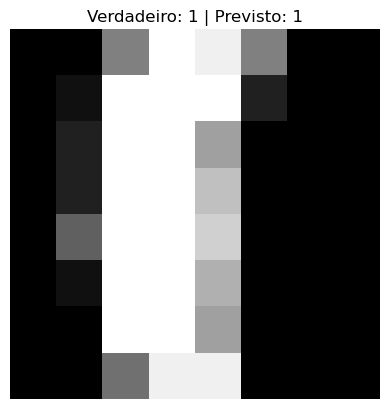

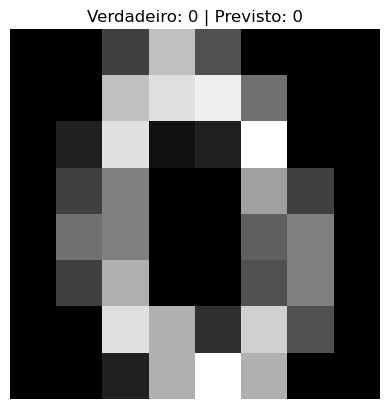

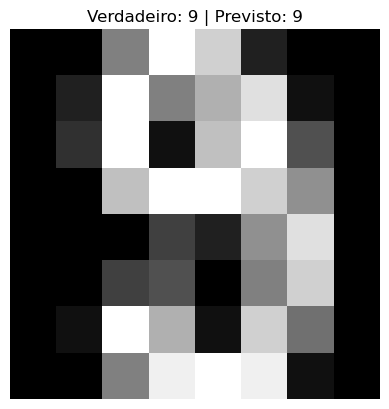

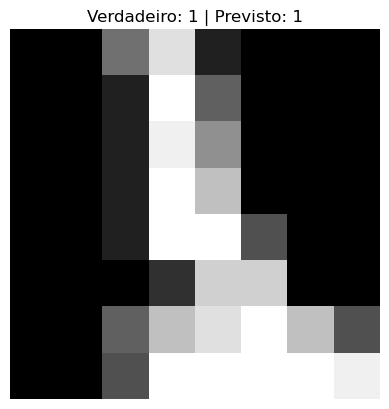

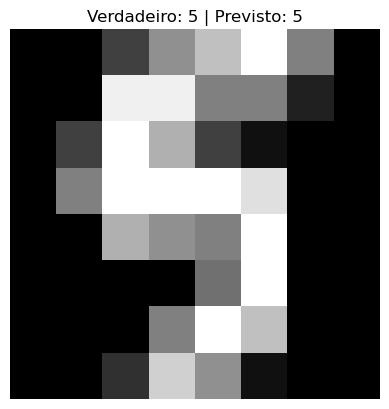

In [18]:
# Visualização
preds = model.predict(X_ts, verbose=0)
y_te_idx = np.argmax(y_ts, axis=1)
for i in range(5):
    plt.imshow(X_ts[i].reshape(8, 8), cmap="gray")
    plt.title(f"Verdadeiro: {y_te_idx[i]} | Previsto: {preds[i].argmax()}")
    plt.axis("off")
    plt.show()

## RNN

In [19]:
import tensorflow as tf
import numpy as np
from tensorflow.keras.datasets import imdb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [20]:
vocab_size = 1000
(x_train, y_train), (x_test, y_test) = imdb.load_data(num_words=vocab_size)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


In [21]:
max_len = 200
x_train = pad_sequences(x_train, maxlen=max_len)
x_test = pad_sequences(x_test, maxlen=max_len)

In [22]:
model = Sequential()
model.add(Embedding(input_dim=vocab_size, output_dim=32, input_length= max_len))
model.add(SimpleRNN(32))
model.add(Dense(1, activation='sigmoid'))

C:\Users\JULYA\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [23]:
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])

In [24]:
model.fit(x_train, y_train, epochs=5, batch_size=132, validation_data=(x_test, y_test))

Epoch 1/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 63s 276ms/step - accuracy: 0.6698 - loss: 0.5972 - val_accuracy: 0.7322 - val_loss: 0.5440
Epoch 2/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 43s 221ms/step - accuracy: 0.7880 - loss: 0.4595 - val_accuracy: 0.8090 - val_loss: 0.4247
Epoch 3/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 117s 398ms/step - accuracy: 0.8320 - loss: 0.3880 - val_accuracy: 0.7940 - val_loss: 0.4386
Epoch 4/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 352s 2s/step - accuracy: 0.8481 - loss: 0.3610 - val_accuracy: 0.8437 - val_loss: 0.3626
Epoch 5/5
190/190 ━━━━━━━━━━━━━━━━━━━━ 0s 776ms/step - accuracy: 0.8653 - loss: 0.3212


KeyboardInterrupt



In [ ]:
loss, acc = model.evaluate(x_test, y_test)
print(f"Acurácia: {acc:.3f}")

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 12ms/step - accuracy: 0.8486 - loss: 0.3621
Acurácia: 0.851


In [ ]:
y_pred_prod = model.predict(x_test)

782/782 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step


In [ ]:
y_pred = ( y_pred_prod >= 0.5).astype(int).flatten()

In [ ]:
acertos = np.sum(y_pred == y_test)
erro = len(y_test) - acertos

In [ ]:
# Visualização
word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"

def decode_review(encoded_review):
    return " ".join([reverse_word_index.get(i, "?") for i in encoded_review])


for i in [0, 1, 2, 3]:
    print(f"\n🔎 Exemplo {i + 1}")
    print("🗨️ Comentário:")
    print(decode_review(x_test[i]))
    print(f"\n🏷️ Rótulo real: {'Positiva' if y_test[i]==1 else 'Negativa'}")
    print(f"🤖 Previsão (probabilidade): {y_pred_prod[i][0]:.2f}")
    print(f"✅ Classificação do modelo: {'Positiva' if y_pred[i]==1 else 'Negativa'}")


1641221/1641221 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step

🔎 Exemplo 1
🗨️ Comentário:
<PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <PAD> <START> please give this one a miss br br <UNK> <UNK> and the rest of the cast <UNK> terrible performances the show is <UNK> <UNK> 